# Study 05 — What if the frame-win probability is uncertain?

In Study 03, we treated a player's probability of winning any individual frame as a known constant:

\[
p = 0.58
\]

That let us ask a relatively simple question: if every frame is independent and the stronger player wins each frame with probability 0.58, how often should that player win a match?

But in real analysis, a value such as 0.58 would usually be **estimated from observed data** rather than known exactly.

That introduces a second kind of uncertainty.

- **Outcome uncertainty:** even if we knew the true value of \(p\), we would not know which player will win the next frame or match.
- **Parameter uncertainty:** we do not know the true value of \(p\) exactly because we estimated it from a finite sample of frames.

In this study we return to the simple independent-frame model from Study 03. We remove the momentum complication from Study 04 entirely.

We change **one assumption only**:

> Instead of assuming \(p = 0.58\) is known exactly, we will treat the underlying frame-win probability as uncertain.

We will then use Monte Carlo simulation to propagate that uncertainty in \(p\) through to uncertainty in the player's match-win probability.

## Where does 0.58 come from?

Suppose we observed a player over 100 frames and they won 58 of them.

Our estimate of their frame-win probability would be:

$$
\hat{p} = \frac{58}{100} = 0.58
$$

The important point is that **0.58 is now an estimate, not a known property of the player**.

Another sample of 100 frames from the same player might have produced 54 wins, 61 wins, or some other number. The observed record contains information about the underlying probability, but it does not identify that probability perfectly.

For now we will deliberately use this simple 58-from-100 example so we can isolate the effect of parameter uncertainty.

In [1]:
# Treat 58 wins from 100 observed frames as the evidence behind our estimate.
observed_wins = 58
observed_frames = 100

p_hat = observed_wins / observed_frames
p_hat

0.58

### The sample size matters

The estimate of 0.58 comes from only **100 observed frames**.

We do not know what would happen if we observed the player for longer. The estimate could rise, fall, or remain close to 0.58 as more evidence arrived.

For example, imagine the player's cumulative record developed like this:

$$
\frac{58}{100} = 0.580
$$

$$
\frac{296}{500} = 0.592
$$

$$
\frac{597}{1000} = 0.597
$$

The estimate changes as more frames are observed.

After 100 frames we might have estimated the player's frame-win probability at 0.58. After 500 frames that estimate has moved to 0.592. After 1,000 frames it has moved again to 0.597.

That does **not** mean an estimate must move steadily closer to the true value every time we observe another frame. We still do not know what the true value is.

But larger samples generally reduce the influence of random variation in a small sample. Our estimate tends to become more stable, and our uncertainty about the underlying probability becomes smaller.

There is another important point. These two records have exactly the same observed win rate:

$$
\frac{58}{100} = 0.58
$$

$$
\frac{580}{1000} = 0.58
$$

But they do not give us the same amount of evidence.

A 58% win rate observed over 1,000 frames gives us much stronger reason to believe the true probability is somewhere near 0.58 than the same win rate observed over only 100 frames.

So our uncertainty depends not just on the estimated probability, but also on **how much evidence produced that estimate**.

For this study we will deliberately stop at 100 observed frames and ask:

> Given only this sample, how uncertain should we be about the true value of \(p\)?

## How does Monte Carlo change when \(p\) is uncertain?

In Study 03, Monte Carlo handled **outcome uncertainty**.

We assumed that the player's true frame-win probability was known:

$$
p = 0.58
$$

We then simulated many matches. The individual frame results varied from simulation to simulation, but the value of \(p\) never changed.

Now we want Monte Carlo to handle **parameter uncertainty as well**.

Instead of feeding every simulation the same value of 0.58, we will allow each simulation to use a plausible value of the unknown true frame-win probability.

Conceptually, each simulation will do two things:

1. Draw a plausible value for \(p\), based on the 58 wins observed in 100 frames.
2. Use that value of \(p\) to simulate future match outcomes.

So the new problem is:

> How should we generate plausible values of \(p\) from the evidence we have observed?

We need a probability distribution over possible values of \(p\). Once we have that, Monte Carlo can sample from it and propagate the uncertainty into the match-level result.

## Turning the sample into plausible values of \(p\)

Monte Carlo now needs a way to generate possible values of the player's **true** frame-win probability.

Those values must lie between 0 and 1, and values supported by the observed 58 wins and 42 losses should be more plausible than values far away from them.

A convenient distribution for this is the **Beta distribution**.

The Beta distribution is not a model of snooker. It is simply a probability distribution for an unknown probability.

We begin with:

$$
p \sim \mathrm{Beta}(1,1)
$$

This is flat between 0 and 1. Before seeing any frames, we are not favouring one possible value of \(p\) over another.

The updating rule is particularly simple:

- each observed win adds 1 to the first number;
- each observed loss adds 1 to the second number.

We observed 58 wins and 42 losses, so:

$$
p \sim \mathrm{Beta}(1 + 58,\ 1 + 42)
$$

which gives:

$$
p \sim \mathrm{Beta}(59,43)
$$

This no longer says:

> \(p\) is exactly 0.58.

Instead it says:

> There is a range of plausible values for \(p\), with values around our observed 58% record receiving much more support than values far away from it.

Monte Carlo can now **draw different plausible values of \(p\)** from this distribution rather than using 0.58 every time.

### Do we need to understand the Beta distribution?

Not really.

For this study, the important thing is what it does, not how to derive it.

If we observe:

- 58 wins
- 42 losses

and start from a simple flat prior, we use:

$$
\mathrm{Beta}(59,43)
$$

That distribution gives us a sensible range of plausible values for the unknown frame-win probability.

You can dig into the mathematics of why this works, but that quickly becomes a statistics lesson in its own right.

For our purposes:

> plug in the wins and losses, trust the mathematicians, and move on.

The job of this study is not to derive the Beta distribution. It is to see what happens when uncertainty in \(p\) is carried through into uncertainty in match-win probability.

## Drawing plausible frame-win probabilities

We now have a distribution representing our uncertainty about the unknown true value of \(p\).

Before simulating any matches, we should look at what Monte Carlo actually draws from it.

Each draw below should be read as:

> One plausible value of the player's true frame-win probability, given the 58 wins observed in 100 frames.

These are **not new observed win rates**. They are possible values of the underlying parameter \(p\). These are possible values of the underlying parameter p that the Beta distribution assigns relatively high probability given the 58 wins and 42 losses we observed.

### Sampling possible values of \(p\)

We now use Monte Carlo to draw values from our Beta distribution.

Each draw represents one possible value of the player's **true underlying frame-win probability** consistent with the evidence we observed.

We are not simulating matches yet.

At this stage we are only asking:

> If 58 wins from 100 frames is all the evidence we have, what values of \(p\) might reasonably be true?

We will draw just 10 values first so we can see what the simulation is actually doing rather than immediately hiding it inside thousands of repetitions.

In [2]:
import numpy as np

rng = np.random.default_rng(42)

# Convert the observed 58 wins and 42 losses into the Beta parameters.
alpha = observed_wins + 1
beta = (observed_frames - observed_wins) + 1

# Draw 10 plausible values for the player's unknown true frame-win probability.
p_draws = rng.beta(alpha, beta, size=10)

p_draws

array([0.56100258, 0.50818779, 0.54601023, 0.56373396, 0.55839665,
       0.52813636, 0.54527528, 0.51517017, 0.53941036, 0.6064692 ])

### What do these draws show?

The 10 draws range from about **0.51 to 0.61**.

Our observed estimate was:

$$
\hat{p} = 0.58
$$

but Monte Carlo is showing us that, given only 100 observed frames, other nearby values of the true frame-win probability are still plausible.

For example:

- one draw is about 0.508;
- several are around 0.54–0.56;
- one is about 0.606.

We should not read too much into the exact balance of these 10 values. Ten draws are only being used to make the mechanism visible.

The important point is that **0.58 is no longer treated as certain**.

We are also **not saying that the player's ability changes from one match to another**. Each draw represents a different possible answer to the same unknown question:

> What is the player's true frame-win probability?

The spread in these values represents **parameter uncertainty**.

Next we can make many more draws to see the shape and scale of that uncertainty properly.

## Increasing the number of Monte Carlo draws

So far we have drawn only 10 possible values of \(p\).

That was enough to show what one Monte Carlo draw means, but 10 draws are far too few to describe the full uncertainty reliably.

We can therefore ask the computer to repeat the **same sampling process** many more times.

We will use:

$$
100{,}000
$$

Monte Carlo draws.

This does **not** mean we now have 100,000 observed frames.

Our evidence about the player has not changed at all. We still have only:

- 100 observed frames;
- 58 wins;
- 42 losses.

Those 100 observed frames determine the Beta distribution and therefore determine how uncertain we are about \(p\).

The 100,000 Monte Carlo draws simply sample that same uncertainty many times so that we can see its shape more clearly and estimate quantities from it more reliably.

So there are now two very different numbers in the study:

> **100 observed frames** = the evidence we actually have.

> **100,000 Monte Carlo draws** = repeated computer samples from the uncertainty implied by that evidence.

Increasing the second number does not improve our knowledge of the player. To do that, we would need more **observed frames**, not more simulation.

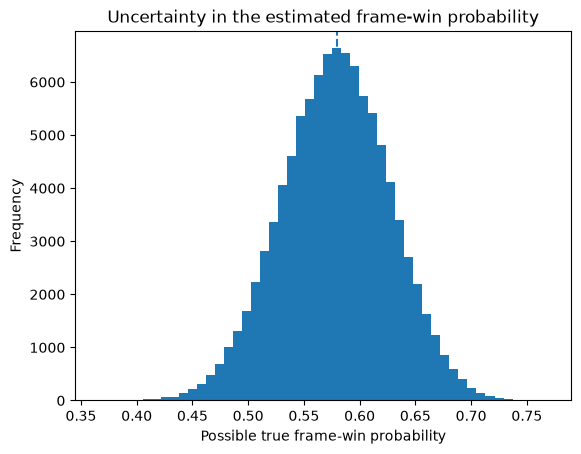

In [3]:
import matplotlib.pyplot as plt

# Draw many plausible values of the unknown true frame-win probability.
p_draws_many = rng.beta(alpha, beta, size=100000)

plt.hist(p_draws_many, bins=50)
plt.axvline(p_hat, linestyle="--")
plt.xlabel("Possible true frame-win probability")
plt.ylabel("Frequency")
plt.title("Uncertainty in the estimated frame-win probability")
plt.show()

### What does the distribution show?

The simulated values form a clear peak around our observed estimate of 0.58.

Values close to 0.58 are drawn most often. As we move farther away from 0.58, the draws become less common.

So the 58 wins from 100 frames are informative, but they do **not** pin the true frame-win probability down very tightly.

The chart also makes the distinction from Study 03 visible.

In Study 03 we effectively assumed:

$$
p = 0.58
$$

Here, 0.58 is only near the centre of a **range of plausible values**.

The width of that distribution is our parameter uncertainty.

We can now put some numbers around that uncertainty rather than judging it only from the chart.

## Measuring the width of the uncertainty

The histogram shows us the shape of the uncertainty in \(p\), but we also want a simple numerical way to describe how wide that uncertainty is.

One way to think about this is to imagine placing two measuring sticks into the distribution.

We put the first stick at the point where only **2.5%** of the Monte Carlo draws lie below it.

We put the second stick at the point where only **2.5%** of the draws lie above it.

The distance between those two sticks contains the **middle 95%** of the plausible values generated by our uncertainty model.

This does not mean values outside that range are impossible. It is simply a convenient way of describing where most of the probability lies.

We will also record the median, which marks the middle of the simulated distribution.

In [4]:
# Find the middle 95% of the plausible p values generated by Monte Carlo.
lower_p, median_p, upper_p = np.quantile(
    p_draws_many,
    [0.025, 0.50, 0.975],
)

lower_p, median_p, upper_p

(np.float64(0.4818573458556267),
 np.float64(0.579189877097829),
 np.float64(0.6716094235560236))

### What does this tell us?

The two measuring sticks land at about:

$$
0.482
$$

and:

$$
0.672
$$

So, under our Beta uncertainty model, the middle 95% of the plausible values for the player's true frame-win probability lies between roughly **48% and 67%**.

The median of the distribution is about:

$$
0.579
$$

which is very close to our original estimate of 0.58.

But the important result is the **width**, not the centre.

After observing only 58 wins from 100 frames, there is still substantial uncertainty about the player's true ability. Plausible values extend from slightly below 50% to well above 60%.

That is very different from simply assuming:

$$
p = 0.58
$$

as a known fact.

We now have something we can propagate through the match model:

> instead of calculating match-win probability for one fixed value of \(p\), we can calculate it repeatedly for many plausible values of \(p\).

## Carrying the uncertainty into a match

We now return to the simple match model from Study 03.

We will start with a **best-of-7** match:

- first player to 4 frames wins;
- frames are independent;
- the player's frame-win probability remains fixed throughout the match;
- there is no momentum or other frame dependence.

In Study 03 we assumed:

$$
p = 0.58
$$

and found the player's match-win probability from that single known value.

Study 05 changes only one thing.

We no longer know exactly what \(p\) is.

Instead, we have 100,000 plausible values of \(p\) drawn from the uncertainty implied by our 58 wins from 100 observed frames.

For each possible value of \(p\), there is a corresponding probability of winning a best-of-7 match.

So we can now propagate the uncertainty forward:

$$
\text{uncertainty in }p
\quad\longrightarrow\quad
\text{uncertainty in match-win probability}
$$

We do not need to simulate the individual frames again to do this.

Because frames are once again independent, we can use the exact best-of-7 calculation from Study 03 for each Monte Carlo draw of \(p\).

The **Monte Carlo part** is drawing the uncertain values of \(p\).

The match calculation then tells us what each of those possible values would mean at match level.

In [5]:
from math import comb

def best_of_7_win_probability(p):
    # In a best-of-7, the player wins by taking at least 4 of the 7 possible frames.
    return sum(
        comb(7, wins) * p**wins * (1 - p)**(7 - wins)
        for wins in range(4, 8)
    )

# First check that the familiar fixed p = 0.58 case gives the result from Study 03.
best_of_7_win_probability(0.58)

0.6705883933695999

At a fixed frame-win probability of:

$$
p = 0.58
$$

the exact probability of winning a best-of-7 match is:

$$
0.6706
$$

or about **67.1%**.

That reproduces the fixed-\(p\) result from Study 03.

This gives us our baseline.

If we knew with certainty that the true frame-win probability was exactly 0.58, we could stop here.

But in this study we do **not** know that. We only estimated \(p\) from 58 wins in 100 observed frames.

The next step is therefore to calculate the best-of-7 match-win probability for every plausible value of \(p\) generated by our Monte Carlo simulation.

## Propagating the uncertainty into match-win probability

We now take each plausible value of \(p\) from our Monte Carlo draws and ask:

> If this were the player's true frame-win probability, what would their chance of winning a best-of-7 match be?

So every sampled value of \(p\) produces a corresponding match-win probability.

For example:

- a lower plausible value of \(p\) will produce a lower match-win probability;
- a higher plausible value of \(p\) will produce a higher match-win probability.

Instead of ending with one number such as 67.1%, we will therefore end with a **distribution of possible match-win probabilities**.

This is parameter uncertainty being carried through the match model.

In [6]:
# Convert every plausible value of p into its corresponding
# best-of-7 match-win probability.
match_win_draws = np.array([
    best_of_7_win_probability(p)
    for p in p_draws_many
])

# Show the first 10 transformations.
list(zip(p_draws_many[:10], match_win_draws[:10]))

[(np.float64(0.6453906407261567), np.float64(0.7924871878990984)),
 (np.float64(0.5529190797669534), np.float64(0.6144724629123924)),
 (np.float64(0.5812591790971346), np.float64(0.6731334986759387)),
 (np.float64(0.6428545509396597), np.float64(0.7882105984100307)),
 (np.float64(0.5741555799253155), np.float64(0.6586940546347181)),
 (np.float64(0.6159997138711647), np.float64(0.7405270491258019)),
 (np.float64(0.5579072684000349), np.float64(0.6249867251932003)),
 (np.float64(0.5359428444494736), np.float64(0.5782199317713705)),
 (np.float64(0.5723074549589886), np.float64(0.6549059219263348)),
 (np.float64(0.5994380585957657), np.float64(0.7091196783468527))]

### What happened to the uncertainty?

Each pair contains:

$$
(\text{possible value of }p,\ \text{corresponding best-of-7 win probability})
$$

For example, one Monte Carlo draw gave:

$$
p \approx 0.623
$$

which would imply a best-of-7 match-win probability of about:

$$
0.754
$$

Another gave:

$$
p \approx 0.559
$$

which implies a match-win probability of about:

$$
0.627
$$

And one relatively high draw of:

$$
p \approx 0.665
$$

becomes a match-win probability of about:

$$
0.824
$$

So uncertainty about the player's frame-win probability has become uncertainty about their chance of winning the match.

Notice that the match probabilities vary **more dramatically** than the underlying frame probabilities.

A few percentage points of uncertainty in \(p\) can translate into a much larger difference in the probability of winning a best-of-7 match.

We have now propagated the parameter uncertainty through the match model.

These are only the first 10 transformations. Next we can look at the full distribution of all 100,000 resulting match-win probabilities.

## Seeing the uncertainty in match-win probability

We now have 100,000 possible best-of-7 match-win probabilities.

They all come from the same 58 wins in 100 observed frames.

The only difference between them is which plausible value of \(p\) was drawn from our uncertainty distribution.

We can plot these match-win probabilities in exactly the same way that we plotted the possible values of \(p\).

This lets us see what happened when the uncertainty in frame-level ability passed through the match structure.

The question is:

> How wide is our uncertainty about the player's chance of winning a best-of-7 match?

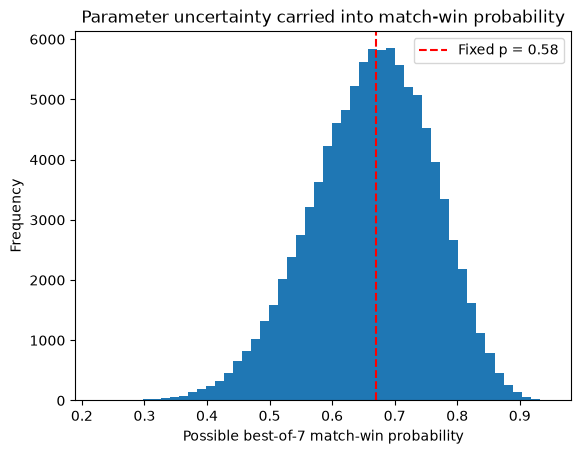

In [7]:
# Plot the match-win probabilities produced by all 100,000 plausible values of p.
plt.hist(match_win_draws, bins=50)

# Mark the fixed-p result from Study 03.
fixed_match_probability = best_of_7_win_probability(0.58)
plt.axvline(
    fixed_match_probability,
    linestyle="--",
    color="red",
    label="Fixed p = 0.58"
)

plt.xlabel("Possible best-of-7 match-win probability")
plt.ylabel("Frequency")
plt.title("Parameter uncertainty carried into match-win probability")
plt.legend()
plt.show()

### What does the match-level distribution show?

The dashed line marks the result we would get if the frame-win probability were known exactly:

$$
p = 0.58
$$

which gives a best-of-7 match-win probability of about:

$$
0.671
$$

But once we acknowledge that \(p\) was only estimated from 100 observed frames, that single answer becomes a distribution.

The important change is the spread.

Our uncertainty about frame-level ability has passed through the match structure and become uncertainty about the chance of winning the match.

The centre is still around the familiar 67% result, but plausible match-win probabilities extend substantially below and above it.

We can now use the same two measuring sticks as before to put numbers around that spread.

## Measuring the match-level uncertainty

We can now use the same idea as before and place two measuring sticks into this new distribution.

This time, however, we are not measuring uncertainty in the frame-win probability \(p\).

We are measuring uncertainty in the player's **best-of-7 match-win probability**.

We will find:

- the point below which only 2.5% of the simulated match-win probabilities fall;
- the median;
- the point above which only 2.5% fall.

The span between the two outer values contains the middle 95% of the match-win probabilities implied by our uncertainty about \(p\).

This will let us compare the single fixed-\(p\) answer of about 67.1% with the much wider range we get when we admit that \(p\) was only estimated.

In [8]:
# Measure the middle 95% of the possible best-of-7 match-win probabilities.
lower_match, median_match, upper_match = np.quantile(
    match_win_draws,
    [0.025, 0.50, 0.975],
)

lower_match, median_match, upper_match

(np.float64(0.4603651557082192),
 np.float64(0.6689475911139577),
 np.float64(0.8342121955639127))

### What does this tell us?

If we treated the frame-win probability as known exactly at:

$$
p = 0.58
$$

we would report a best-of-7 match-win probability of about:

$$
0.671
$$

or **67.1%**.

But once we acknowledge that the 0.58 estimate came from only 58 wins in 100 observed frames, the answer becomes much less precise.

The middle 95% of the match-win probabilities implied by our uncertainty in \(p\) runs from about:

$$
0.461
$$

to:

$$
0.836
$$

or roughly **46% to 84%**.

The median is about:

$$
0.668
$$

which remains very close to the original fixed-\(p\) answer.

So the central estimate has barely changed.

What has changed dramatically is **how certain we should be about it**.

With only 100 observed frames, a best-of-7 match-win probability below 50% is still within the central 95% of plausible values, while values above 80% are also plausible.

That is the distinction this study was designed to expose:

> **Outcome uncertainty** says that even if the true match-win probability were known to be 67.1%, we would still not know who will win a particular match.

> **Parameter uncertainty** says that, from this limited sample, we are not even sure that 67.1% is the correct match-win probability in the first place.

Monte Carlo has carried that uncertainty in the estimated frame probability through to the quantity we actually care about: the probability of winning the match.

## What if 58% came from 1,000 observed frames?

Earlier we noted that these two records have the same estimated frame-win probability:

$$
\frac{58}{100} = 0.58
$$

$$
\frac{580}{1000} = 0.58
$$

But the second record contains much more evidence.

Nothing about the central estimate changes. In both cases:

$$
\hat{p} = 0.58
$$

What should change is our **uncertainty around that estimate**.

If 580 wins from 1,000 frames still produced a very wide range of plausible values for \(p\), then observing more data would have achieved very little.

So we will repeat exactly the same uncertainty calculation, changing only the sample size from 100 observed frames to 1,000.

In [9]:
# Keep the observed win rate at exactly 58%, but increase the evidence tenfold.
observed_wins_1000 = 580
observed_frames_1000 = 1000

# Apply the same flat-prior Beta update used for the 100-frame sample.
alpha_1000 = observed_wins_1000 + 1
beta_1000 = (observed_frames_1000 - observed_wins_1000) + 1

# Draw the same number of Monte Carlo samples so only the evidence has changed.
p_draws_1000 = rng.beta(alpha_1000, beta_1000, size=100_000)

# Measure the middle 95% of the plausible values of p.
np.quantile(p_draws_1000, [0.025, 0.50, 0.975])

array([0.54915636, 0.5797498 , 0.61016342])

### What changed when we observed more frames?

The estimated frame-win probability is still:

$$
\hat{p} = 0.58
$$

But the uncertainty around it has become much narrower.

With **100 observed frames**, the middle 95% of plausible values for \(p\) was approximately:

$$
0.482 \text{ to } 0.672
$$

With **1,000 observed frames**, it is approximately:

$$
0.549 \text{ to } 0.610
$$

The centre has barely moved. The median is still about 0.58.

What changed is the **precision** of the estimate.

With only 100 frames, quite a wide range of underlying abilities was compatible with the evidence.

With 1,000 frames, values much farther away from 0.58 have become much harder to reconcile with what we observed.

This demonstrates an important point:

> More Monte Carlo simulations do not reduce our uncertainty about the player. More observed frames do.

The 100,000 simulations simply reveal the uncertainty implied by the evidence. Increasing the evidence from 100 to 1,000 frames is what actually makes that uncertainty narrower.

Now we can see what this greater certainty about \(p\) does to our uncertainty about the player's best-of-7 match-win probability.

In [10]:
# Carry the narrower uncertainty in p through the same best-of-7 match model.
match_win_draws_1000 = np.array([
    best_of_7_win_probability(p)
    for p in p_draws_1000
])

# Measure the middle 95% of the resulting match-win probabilities.
np.quantile(match_win_draws_1000, [0.025, 0.50, 0.975])

array([0.60649623, 0.67008192, 0.72962103])

### What happened at match level?

With **100 observed frames**, the middle 95% of plausible best-of-7 match-win probabilities was approximately:

$$
0.461 \text{ to } 0.836
$$

or about **46% to 84%**.

With **1,000 observed frames**, that range has narrowed to approximately:

$$
0.606 \text{ to } 0.730
$$

or about **61% to 73%**.

Again, the centre has barely changed. The median match-win probability is still about 67%.

What changed is how uncertain we are about that number.

With only 100 observed frames, our uncertainty about the underlying frame-win probability was large enough that a match-win probability below 50% was still plausible.

After 1,000 observed frames at the same 58% win rate, the evidence is much stronger. The plausible match-win probabilities are now concentrated much more tightly around the original 67% estimate.

So the important lesson is not:

> More data changed our estimate from 67% to something else.

It is:

> More data gave us much stronger grounds for believing that an answer near 67% is actually the right one.

This is the practical effect of reducing **parameter uncertainty**.

## Comparing the two levels of evidence directly

We can now put the two match-level uncertainty distributions on the same graph.

Both cases have exactly the same observed frame-win rate:

$$
\hat{p} = 0.58
$$

The only difference is how much evidence produced that estimate:

- 58 wins from 100 frames;
- 580 wins from 1,000 frames.

Both distributions are based on 100,000 Monte Carlo draws, so changing the number of simulations is not driving the comparison.

If sample size matters in the way we expect, the 1,000-frame distribution should be much more tightly concentrated around the fixed-\(p\) result.

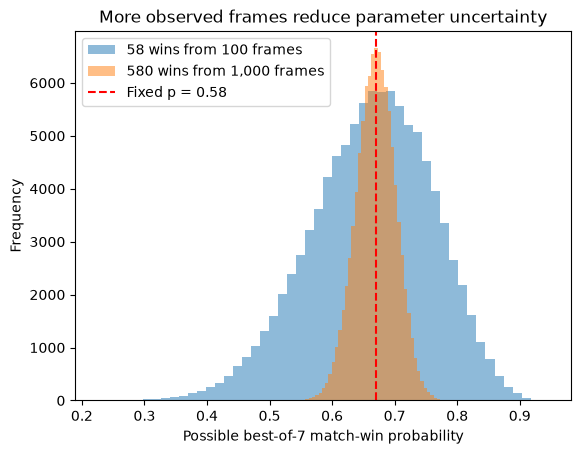

In [11]:
# Compare the match-level uncertainty produced by 100 versus 1,000 observed frames.
plt.hist(
    match_win_draws,
    bins=50,
    alpha=0.5,
    label="58 wins from 100 frames",
)

plt.hist(
    match_win_draws_1000,
    bins=50,
    alpha=0.5,
    label="580 wins from 1,000 frames",
)

# Mark the match-win probability obtained if p were known to be exactly 0.58.
plt.axvline(
    fixed_match_probability,
    linestyle="--",
    color="red",
    label="Fixed p = 0.58",
)

plt.xlabel("Possible best-of-7 match-win probability")
plt.ylabel("Frequency")
plt.title("More observed frames reduce parameter uncertainty")
plt.legend()
plt.show()

### What does the comparison show?

Both distributions are centred close to the same match-win probability.

That makes sense because both samples produced exactly the same observed frame-win rate:

$$
\hat{p} = 0.58
$$

The red dashed line shows the answer we would get if we treated that 58% frame-win probability as known exactly: about **67.1%** for a best-of-7 match.

The difference between the two distributions is their **width**.

With only 100 observed frames, the blue distribution is very wide. Many substantially different match-win probabilities remain compatible with the limited evidence.

With 1,000 observed frames, the orange distribution is much narrower and concentrated around the same central value.

So observing more frames has not materially changed our best estimate.

It has changed **how confident we can be in that estimate**.

This is the central result of Study 05:

> A point estimate such as 58% hides how uncertain we are about the underlying parameter.

And that hidden uncertainty matters because it passes through the match model.

More Monte Carlo simulations make that uncertainty easier to measure.

More **observed data** is what actually reduces it.

## Conclusion

Study 03 separated match outcomes from player strength by assuming the frame-win probability was known exactly.

Under that assumption:

$$
p = 0.58
$$

gave a best-of-7 match-win probability of about:

$$
0.671
$$

Study 05 changed only one assumption:

> the 58% frame-win probability was treated as an estimate from observed data rather than a known constant.

That introduced **parameter uncertainty**.

With 58 wins from only 100 observed frames, the middle 95% of plausible values for the true frame-win probability was roughly:

$$
0.482 \text{ to } 0.672
$$

When that uncertainty was propagated through the best-of-7 match model, the middle 95% of plausible match-win probabilities became roughly:

$$
0.461 \text{ to } 0.836
$$

So the fixed estimate of about 67% was still near the centre, but there was much more uncertainty around it than the single number suggested.

When the same observed 58% win rate was instead based on 1,000 frames, the uncertainty became much narrower.

The middle 95% of plausible match-win probabilities fell to approximately:

$$
0.606 \text{ to } 0.730
$$

The central estimate barely changed.

What changed was how strongly the evidence supported it.

This gives us two distinct kinds of uncertainty:

- **Outcome uncertainty** — even if we know the true probability of winning the match, we still do not know who will actually win.
- **Parameter uncertainty** — we may not know the true probability of winning the match very precisely in the first place, because the underlying frame probability was estimated from limited data.

Monte Carlo is useful here because it allows uncertainty in an input parameter to be carried through the model into uncertainty in the final quantity we care about.

The important practical lesson is:

> A probability estimate should not automatically be treated as if it were a known probability.

How much evidence produced the estimate matters.